In [2]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix



In [3]:
df = pd.read_csv(r'/home/yogendra/Downloads/MedTech_Masterchart - Sheet1.csv')

In [4]:
df

,Sno,Name,Age,date,month,year,weight,height,Pulse rate,Place of birth,...,Unnamed: 197,Unnamed: 198,Unnamed: 199,Unnamed: 200,Unnamed: 201,Resemblance to the animals,Acquirement of wealth / means of living (success in life in view of material and financial gain),At what age skin and muscle changes became apparent,with age changes that have occurred to the hair,what changes do you mark with your bowel habits
0,1,Prema Ram,60,26,7,1964,75,168,73,jodhpur,...,NaN,NaN,NaN,NaN,NaN,22,2.0,NaN,1.0,NaN
1,2,Achala Ram,61,4,5,1963,65,165,91,jodhpur,...,NaN,4.0,NaN,9.0,NaN,14,1.0,NaN,1.0,NaN
2,3,Tulcha Ram Gaur,56,2,8,1968,70,170,88,hanumangarh,...,NaN,NaN,NaN,NaN,NaN,12,2.0,NaN,1.0,NaN
3,4,Kamlesh Kharwal,46,24,8,1978,67,185,72,pali,...,NaN,NaN,NaN,NaN,NaN,23,2.0,NaN,1.0,NaN
4,5,Dharam Singh,63,24,8,1961,67,185,85,pali,...,NaN,NaN,NaN,NaN,NaN,22,2.0,NaN,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,222,Haidar,61,21,10,1963,75,176,76,jodhpur,...,NaN,NaN,NaN,NaN,NaN,25,2.0,NaN,1.0,NaN
222,223,Jaikishan,51,9,2,1973,69,175,71,merta road,...,NaN,NaN,NaN,NaN,NaN,13,2.0,NaN,1.0,NaN
223,224,Harji Ram,70,2,7,1954,61,166,77,"baodi, jodhpur",...,NaN,NaN,NaN,NaN,NaN,23,2.0,NaN,1.0,NaN
224,225,Gulam mohammad,75,12,4,1949,52,176,74,barmer,...,NaN,NaN,NaN,NaN,NaN,22,2.0,NaN,1.0,NaN


In [5]:
df.shape

(226, 207)

In [6]:
df.head()

,Sno,Name,Age,date,month,year,weight,height,Pulse rate,Place of birth,...,Unnamed: 197,Unnamed: 198,Unnamed: 199,Unnamed: 200,Unnamed: 201,Resemblance to the animals,Acquirement of wealth / means of living (success in life in view of material and financial gain),At what age skin and muscle changes became apparent,with age changes that have occurred to the hair,what changes do you mark with your bowel habits
0,1,Prema Ram,60,26,7,1964,75,168,73,jodhpur,...,NaN,NaN,NaN,NaN,NaN,22,2.0,NaN,1.0,NaN
1,2,Achala Ram,61,4,5,1963,65,165,91,jodhpur,...,NaN,4.0,NaN,9.0,NaN,14,1.0,NaN,1.0,NaN
2,3,Tulcha Ram Gaur,56,2,8,1968,70,170,88,hanumangarh,...,NaN,NaN,NaN,NaN,NaN,12,2.0,NaN,1.0,NaN
3,4,Kamlesh Kharwal,46,24,8,1978,67,185,72,pali,...,NaN,NaN,NaN,NaN,NaN,23,2.0,NaN,1.0,NaN
4,5,Dharam Singh,63,24,8,1961,67,185,85,pali,...,NaN,NaN,NaN,NaN,NaN,22,2.0,NaN,1.0,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Columns: 207 entries, Sno to what changes do you mark with your bowel habits
dtypes: float64(79), int64(121), object(7)
memory usage: 365.6+ KB


In [8]:
df = df.drop(['Sno', 'Name', 'Place of birth', 'date', 'month', 'year'], axis=1)

In [9]:
df.head(3)

,Age,weight,height,Pulse rate,CR,Sex,Site,staging (TNM),Staging,Prakriti,...,Unnamed: 197,Unnamed: 198,Unnamed: 199,Unnamed: 200,Unnamed: 201,Resemblance to the animals,Acquirement of wealth / means of living (success in life in view of material and financial gain),At what age skin and muscle changes became apparent,with age changes that have occurred to the hair,what changes do you mark with your bowel habits
0,60,75,168,73,989262301556520,1,Hypopharyngeal,T2N2cM0,IVA,Kv,...,NaN,NaN,NaN,NaN,NaN,22,2.0,NaN,1.0,NaN
1,61,65,165,91,989262301344366,1,Glottis,T3N1M0,IVA,Pv,...,NaN,4.0,NaN,9.0,NaN,14,1.0,NaN,1.0,NaN
2,56,70,170,88,989262300195481,1,Glottis,T2N0M0,II,vpk,...,NaN,NaN,NaN,NaN,NaN,12,2.0,NaN,1.0,NaN


In [10]:
print(df.isnull().sum().sort_values(ascending=False).head(30))


Unnamed: 177                                           226
Unnamed: 194                                           226
Unnamed: 193                                           226
Teeth                                                  226
Unnamed: 118                                           226
Unnamed: 131                                           226
Unnamed: 132                                           226
Unnamed: 126                                           226
Unnamed: 125                                           226
Unnamed: 144                                           226
Unnamed: 156                                           226
Unnamed: 170                                           226
Unnamed: 174                                           226
At what age skin and muscle changes became apparent    226
what changes do you mark with your bowel habits        226
Unnamed: 201                                           226
Unnamed: 199                                           2

In [11]:
columns_to_drop = df.isnull().sum().sort_values(ascending=False).head(30).index

In [12]:
columns_to_drop

Index(['Unnamed: 177', 'Unnamed: 194', 'Unnamed: 193', 'Teeth', 'Unnamed: 118',
       'Unnamed: 131', 'Unnamed: 132', 'Unnamed: 126', 'Unnamed: 125',
       'Unnamed: 144', 'Unnamed: 156', 'Unnamed: 170', 'Unnamed: 174',
       'At what age skin and muscle changes became apparent',
       'what changes do you mark with your bowel habits', 'Unnamed: 201',
       'Unnamed: 199', 'Unnamed: 197',
       'The calf muscles (muscle tone of calves)', 'Unnamed: 129',
       'The color of the body hair', 'Unnamed: 168', 'Unnamed: 167',
       'Unnamed: 169', 'Unnamed: 173', 'Unnamed: 180', 'Unnamed: 200',
       'Unnamed: 198', 'Capacity to retain thirst', 'Unnamed: 172'],
      dtype='object')

In [13]:
df = df.drop(columns_to_drop, axis=1)

In [14]:
df

,Age,weight,height,Pulse rate,CR,Sex,Site,staging (TNM),Staging,Prakriti,...,Unnamed: 188,Concentration,Decisive power,Performance in field of wisdom,Unnamed: 192,66 Other qualities,Unnamed: 196,Resemblance to the animals,Acquirement of wealth / means of living (success in life in view of material and financial gain),with age changes that have occurred to the hair
0,60,75,168,73,989262301556520,1,Hypopharyngeal,T2N2cM0,IVA,Kv,...,5.0,2,2,2,3.0,3,11.0,22,2.0,1.0
1,61,65,165,91,989262301344366,1,Glottis,T3N1M0,IVA,Pv,...,NaN,1,1,2,3.0,1,2.0,14,1.0,1.0
2,56,70,170,88,989262300195481,1,Glottis,T2N0M0,II,vpk,...,5.0,2,2,2,3.0,3,11.0,12,2.0,1.0
3,46,67,185,72,989262301521055,1,Oropharyngeal,T4bN2cM0,IVB,Kv,...,5.0,2,2,2,3.0,3,11.0,23,2.0,1.0
4,63,67,185,85,989262301446151,1,Oropharyngeal,T2N0M0,II,Pv,...,5.0,2,2,2,3.0,3,11.0,22,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,61,75,176,76,989262500773683,1,Hypopharyngeal,T3N0M0,III,Kv,...,5.0,2,2,2,3.0,3,11.0,25,2.0,1.0
222,51,69,175,71,989262502652703,1,Oral cavity,T4aN2bM0,IVB,P,...,5.0,2,2,2,3.0,3,11.0,13,2.0,1.0
223,70,61,166,77,989262500854772,1,Glottic,T3N0M0,III,Kv,...,5.0,2,2,2,3.0,3,11.0,23,2.0,1.0
224,75,52,176,74,989262501025800,1,Oropharyngeal,T3N1M0,IVA,Vk,...,5.0,2,2,2,3.0,3,11.0,22,2.0,1.0


In [15]:
df = df.drop(['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'Q29', 'Q30','Q31','Q32','Q33','Q34','Q35','Q36'], axis=1)

In [16]:
df.shape

(226, 135)

In [17]:
df.head(3)

,Age,weight,height,Pulse rate,CR,Sex,Site,staging (TNM),Staging,Prakriti,...,Unnamed: 188,Concentration,Decisive power,Performance in field of wisdom,Unnamed: 192,66 Other qualities,Unnamed: 196,Resemblance to the animals,Acquirement of wealth / means of living (success in life in view of material and financial gain),with age changes that have occurred to the hair
0,60,75,168,73,989262301556520,1,Hypopharyngeal,T2N2cM0,IVA,Kv,...,5.0,2,2,2,3.0,3,11.0,22,2.0,1.0
1,61,65,165,91,989262301344366,1,Glottis,T3N1M0,IVA,Pv,...,NaN,1,1,2,3.0,1,2.0,14,1.0,1.0
2,56,70,170,88,989262300195481,1,Glottis,T2N0M0,II,vpk,...,5.0,2,2,2,3.0,3,11.0,12,2.0,1.0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Columns: 135 entries, Age to with age changes that have occurred to the hair
dtypes: float64(49), int64(81), object(5)
memory usage: 238.5+ KB


In [19]:
df['Site'].value_counts()

Site
Oral cavity                 62
Supraglottic                39
Glottic                     33
Hypopharyngeal              30
Oropharyngeal               23
Sinonasal carcinoma         10
Nasopharyngeal Carcinoma     8
Maxillary sinus              5
Sinonasal Carcinoma          4
Glottis                      3
Esophagus                    2
Esophageal                   1
Oropharynx                   1
Sinonasal chondrosarcoma     1
sinonasal carcinoma          1
Sinonasal Sarcoma            1
Nasopharyngeal carcinoma     1
Transglottic                 1
Name: count, dtype: int64

In [20]:
print(df.columns.tolist())

['Age', 'weight', 'height', 'Pulse rate', 'CR', 'Sex', 'Site', 'staging (TNM)', 'Staging', 'Prakriti', 'Pain', 'SF 36', 'Value_Q1', 'Value_Q2', 'Value_Q3', 'Value_Q4', 'Value_Q5', 'Value_Q6', 'Value_Q7', 'Value_Q8', 'Value_Q9', 'Value_Q10', 'Value_Q11', 'Value_Q12', 'Value_Q13', 'Value_Q14', 'Value_Q15', 'Value_Q16', 'Value_Q17', 'Value_Q18', 'Value_Q19', 'Value_Q20', 'Value_Q21', 'Value_Q22', 'Value_Q23', 'Value_Q24', 'Value_Q25', 'Value_Q26', 'Value_Q27', 'Value_Q28', 'Value_Q29', 'Value_Q30', 'Value_Q31', 'Value_Q32', 'Value_Q33', 'Value_Q34', 'Value_Q35', 'Value_Q36', 'Prakriti.1', 'Vatta', 'Pitta', 'Kapha', '1. The built', 'The body stature / physique (body frame, height)', 'Unnamed: 96', 'The body parts look like', 'The body smell is (body odor)', 'The general appearance', 'The size of the forehead', 'The Hands (length of hand from shoulder to tip of middle finger)', 'The chest (massiveness of chest)', 'The appearance of joints', 'Unnamed: 104', 'The functioning of the joints', '

In [21]:
for col in df.columns:
    print(f'{col}: {df[col].dtypes}')

Age: int64
weight: int64
height: int64
Pulse rate: int64
CR: int64
Sex: int64
Site: object
staging (TNM): object
Staging: object
Prakriti: object
Pain: int64
SF 36: int64
Value_Q1: int64
Value_Q2: int64
Value_Q3: int64
Value_Q4: int64
Value_Q5: int64
Value_Q6: int64
Value_Q7: int64
Value_Q8: int64
Value_Q9: int64
Value_Q10: int64
Value_Q11: int64
Value_Q12: int64
Value_Q13: int64
Value_Q14: int64
Value_Q15: int64
Value_Q16: int64
Value_Q17: int64
Value_Q18: int64
Value_Q19: int64
Value_Q20: int64
Value_Q21: int64
Value_Q22: int64
Value_Q23: int64
Value_Q24: int64
Value_Q25: int64
Value_Q26: int64
Value_Q27: int64
Value_Q28: int64
Value_Q29: int64
Value_Q30: int64
Value_Q31: int64
Value_Q32: int64
Value_Q33: int64
Value_Q34: int64
Value_Q35: int64
Value_Q36: int64
Prakriti.1: object
Vatta: float64
Pitta: int64
Kapha: float64
1. The built: int64
The body stature / physique (body frame, height): int64
Unnamed: 96: float64
The body parts look like: int64
The body smell is (body odor): floa

In [22]:
df['Site'] = df['Site'].str.lower().str.strip()
counts = df['Site'].value_counts()
less = counts[counts<5].index
print(less)
df['Site'] = df['Site'].replace(less, 'other')

Index(['glottis', 'esophagus', 'esophageal', 'sinonasal chondrosarcoma',
       'oropharynx', 'sinonasal sarcoma', 'transglottic'],
      dtype='object', name='Site')


In [23]:
df.shape

(226, 135)

In [24]:
df = pd.get_dummies(df, columns=['Site'], drop_first=True)


In [25]:
df.head()

,Age,weight,height,Pulse rate,CR,Sex,staging (TNM),Staging,Prakriti,Pain,...,Acquirement of wealth / means of living (success in life in view of material and financial gain),with age changes that have occurred to the hair,Site_hypopharyngeal,Site_maxillary sinus,Site_nasopharyngeal carcinoma,Site_oral cavity,Site_oropharyngeal,Site_other,Site_sinonasal carcinoma,Site_supraglottic
0,60,75,168,73,989262301556520,1,T2N2cM0,IVA,Kv,6,...,2.0,1.0,True,False,False,False,False,False,False,False
1,61,65,165,91,989262301344366,1,T3N1M0,IVA,Pv,8,...,1.0,1.0,False,False,False,False,False,True,False,False
2,56,70,170,88,989262300195481,1,T2N0M0,II,vpk,5,...,2.0,1.0,False,False,False,False,False,True,False,False
3,46,67,185,72,989262301521055,1,T4bN2cM0,IVB,Kv,8,...,2.0,1.0,False,False,False,False,True,False,False,False
4,63,67,185,85,989262301446151,1,T2N0M0,II,Pv,5,...,2.0,1.0,False,False,False,False,True,False,False,False


In [26]:
df.shape

(226, 142)

In [27]:
df['staging (TNM)'].value_counts()


staging (TNM)
T3N1M0        90
T3N0M0        32
T4aN2cM0      17
T4aN0M0       14
T2N2cM0       11
T2N1M0         8
T4aN2bM0       7
T2N3bM0        7
T2N0M0         6
T4aN1M0        5
T3N2cM0        4
T1bN0M0        3
T3N3bM0        3
T2N2bM0        2
T3N2bM0        2
T4aN3bM0       2
T4N0M0         2
T4bN2cM0       1
T3N3bM1        1
T1aN0M0        1
ryT2N1M0       1
T1N1M0         1
ryT4aN2cM0     1
T4N1M0         1
T4N2cM0        1
T3N2aM0        1
T4N3bM0        1
T4aN2aM0       1
Name: count, dtype: int64

In [28]:
import re
def split_tnm(tnm):
    t = re.search(r'T([0-4][a-b]?)',tnm)
    n = re.search(r'N([0-3][a-cb]?)',tnm)
    m = re.search(r'M([0-1])',tnm)
    return pd.Series({
        'T': t.group(1) if t else None,
        'N': n.group(1) if n else None,
        'M': m.group(1) if m else None
    })
df[['Tumorsize', 'Lymphnodes', 'Metastasis']] = df['staging (TNM)'].apply(split_tnm)

In [29]:
df['Tumorsize'] = df['Tumorsize'].replace({
    '1a': 1,'1b':1, '1': 1,
    '2': 2,
    '3': 3,
    '4a': 4, '4b': 4, '4': 4
})
df['Tumorsize']= df['Tumorsize'].astype(float)

df['Lymphnodes'] = df['Lymphnodes'].replace({
    '0': 0,
    '1': 1,
    '2a': 2, '2b': 2, '2c': 2, '2': 2,
    '3a': 3, '3b': 3,'3': 3
})

df['Lymphnodes'] = df['Lymphnodes'].astype(float)



df['Metastasis'] = df['Metastasis'].astype(float)

/tmp/ipykernel_65508/3062954116.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Tumorsize'] = df['Tumorsize'].replace({
/tmp/ipykernel_65508/3062954116.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Lymphnodes'] = df['Lymphnodes'].replace({


In [30]:
df = df.drop('staging (TNM)', axis=1)

In [31]:
df.head()

,Age,weight,height,Pulse rate,CR,Sex,Staging,Prakriti,Pain,SF 36,...,Site_maxillary sinus,Site_nasopharyngeal carcinoma,Site_oral cavity,Site_oropharyngeal,Site_other,Site_sinonasal carcinoma,Site_supraglottic,Tumorsize,Lymphnodes,Metastasis
0,60,75,168,73,989262301556520,1,IVA,Kv,6,2190,...,False,False,False,False,False,False,False,2.0,2.0,0.0
1,61,65,165,91,989262301344366,1,IVA,Pv,8,1990,...,False,False,False,False,True,False,False,3.0,1.0,0.0
2,56,70,170,88,989262300195481,1,II,vpk,5,2015,...,False,False,False,False,True,False,False,2.0,0.0,0.0
3,46,67,185,72,989262301521055,1,IVB,Kv,8,1335,...,False,False,False,True,False,False,False,4.0,2.0,0.0
4,63,67,185,85,989262301446151,1,II,Pv,5,2315,...,False,False,False,True,False,False,False,2.0,0.0,0.0


In [32]:
for col in df.columns:
    print(f'{col}: {df[col].dtypes}')

Age: int64
weight: int64
height: int64
Pulse rate: int64
CR: int64
Sex: int64
Staging: object
Prakriti: object
Pain: int64
SF 36: int64
Value_Q1: int64
Value_Q2: int64
Value_Q3: int64
Value_Q4: int64
Value_Q5: int64
Value_Q6: int64
Value_Q7: int64
Value_Q8: int64
Value_Q9: int64
Value_Q10: int64
Value_Q11: int64
Value_Q12: int64
Value_Q13: int64
Value_Q14: int64
Value_Q15: int64
Value_Q16: int64
Value_Q17: int64
Value_Q18: int64
Value_Q19: int64
Value_Q20: int64
Value_Q21: int64
Value_Q22: int64
Value_Q23: int64
Value_Q24: int64
Value_Q25: int64
Value_Q26: int64
Value_Q27: int64
Value_Q28: int64
Value_Q29: int64
Value_Q30: int64
Value_Q31: int64
Value_Q32: int64
Value_Q33: int64
Value_Q34: int64
Value_Q35: int64
Value_Q36: int64
Prakriti.1: object
Vatta: float64
Pitta: int64
Kapha: float64
1. The built: int64
The body stature / physique (body frame, height): int64
Unnamed: 96: float64
The body parts look like: int64
The body smell is (body odor): float64
The general appearance: int64
T

In [33]:
df['Staging'].value_counts()

Staging
IVA    134
III     42
IVB     38
II       7
I        4
IVC      1
Name: count, dtype: int64

In [34]:
df['Staging'] = df['Staging'].replace({
    'I': 6,
    'II': 5,
    'III': 4,
    'IVA': 3,
    'IVB': 2,
    'IVC': 1
})

df['Staging'] = df['Staging'].astype(float)

/tmp/ipykernel_65508/2952095205.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Staging'] = df['Staging'].replace({


In [35]:
df

,Age,weight,height,Pulse rate,CR,Sex,Staging,Prakriti,Pain,SF 36,...,Site_maxillary sinus,Site_nasopharyngeal carcinoma,Site_oral cavity,Site_oropharyngeal,Site_other,Site_sinonasal carcinoma,Site_supraglottic,Tumorsize,Lymphnodes,Metastasis
0,60,75,168,73,989262301556520,1,3.0,Kv,6,2190,...,False,False,False,False,False,False,False,2.0,2.0,0.0
1,61,65,165,91,989262301344366,1,3.0,Pv,8,1990,...,False,False,False,False,True,False,False,3.0,1.0,0.0
2,56,70,170,88,989262300195481,1,5.0,vpk,5,2015,...,False,False,False,False,True,False,False,2.0,0.0,0.0
3,46,67,185,72,989262301521055,1,2.0,Kv,8,1335,...,False,False,False,True,False,False,False,4.0,2.0,0.0
4,63,67,185,85,989262301446151,1,5.0,Pv,5,2315,...,False,False,False,True,False,False,False,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,61,75,176,76,989262500773683,1,4.0,Kv,3,2315,...,False,False,False,False,False,False,False,3.0,0.0,0.0
222,51,69,175,71,989262502652703,1,2.0,P,3,2185,...,False,False,True,False,False,False,False,4.0,2.0,0.0
223,70,61,166,77,989262500854772,1,4.0,Kv,4,1860,...,False,False,False,False,False,False,False,3.0,0.0,0.0
224,75,52,176,74,989262501025800,1,3.0,Vk,3,2290,...,False,False,False,True,False,False,False,3.0,1.0,0.0


In [36]:
df['Prakriti'].value_counts()

Prakriti
Kv     83
K      49
Vk     33
vpk    18
Pv     11
Kp      7
P       5
Pk      4
V       4
PK      4
KP      3
KV      2
Vp      2
k       1
Name: count, dtype: int64

In [37]:
df['Prakriti'] = df['Prakriti'].str.upper().str.strip()
df['Prakriti']  = df['Prakriti'].apply(lambda x: ''.join(sorted(x)) if isinstance(x, str) else x)

df['Vata'] = df['Prakriti'].apply(lambda x: 1 if 'V' in x else 0)
df['Pitta'] = df['Prakriti'].apply(lambda x: 1 if 'P' in x else 0)
df['Kapha'] = df['Prakriti'].apply(lambda x: 1 if 'K' in x else 0)
df= df.drop('Prakriti', axis=1)

In [38]:
df

,Age,weight,height,Pulse rate,CR,Sex,Staging,Pain,SF 36,Value_Q1,...,Site_nasopharyngeal carcinoma,Site_oral cavity,Site_oropharyngeal,Site_other,Site_sinonasal carcinoma,Site_supraglottic,Tumorsize,Lymphnodes,Metastasis,Vata
0,60,75,168,73,989262301556520,1,3.0,6,2190,50,...,False,False,False,False,False,False,2.0,2.0,0.0,1
1,61,65,165,91,989262301344366,1,3.0,8,1990,0,...,False,False,False,True,False,False,3.0,1.0,0.0,1
2,56,70,170,88,989262300195481,1,5.0,5,2015,0,...,False,False,False,True,False,False,2.0,0.0,0.0,1
3,46,67,185,72,989262301521055,1,2.0,8,1335,0,...,False,False,True,False,False,False,4.0,2.0,0.0,1
4,63,67,185,85,989262301446151,1,5.0,5,2315,50,...,False,False,True,False,False,False,2.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,61,75,176,76,989262500773683,1,4.0,3,2315,50,...,False,False,False,False,False,False,3.0,0.0,0.0,1
222,51,69,175,71,989262502652703,1,2.0,3,2185,50,...,False,True,False,False,False,False,4.0,2.0,0.0,0
223,70,61,166,77,989262500854772,1,4.0,4,1860,0,...,False,False,False,False,False,False,3.0,0.0,0.0,1
224,75,52,176,74,989262501025800,1,3.0,3,2290,0,...,False,False,True,False,False,False,3.0,1.0,0.0,1


In [39]:
for col in df.columns:
    print(f'{col}: {df[col].dtypes}')

Age: int64
weight: int64
height: int64
Pulse rate: int64
CR: int64
Sex: int64
Staging: float64
Pain: int64
SF 36: int64
Value_Q1: int64
Value_Q2: int64
Value_Q3: int64
Value_Q4: int64
Value_Q5: int64
Value_Q6: int64
Value_Q7: int64
Value_Q8: int64
Value_Q9: int64
Value_Q10: int64
Value_Q11: int64
Value_Q12: int64
Value_Q13: int64
Value_Q14: int64
Value_Q15: int64
Value_Q16: int64
Value_Q17: int64
Value_Q18: int64
Value_Q19: int64
Value_Q20: int64
Value_Q21: int64
Value_Q22: int64
Value_Q23: int64
Value_Q24: int64
Value_Q25: int64
Value_Q26: int64
Value_Q27: int64
Value_Q28: int64
Value_Q29: int64
Value_Q30: int64
Value_Q31: int64
Value_Q32: int64
Value_Q33: int64
Value_Q34: int64
Value_Q35: int64
Value_Q36: int64
Prakriti.1: object
Vatta: float64
Pitta: int64
Kapha: int64
1. The built: int64
The body stature / physique (body frame, height): int64
Unnamed: 96: float64
The body parts look like: int64
The body smell is (body odor): float64
The general appearance: int64
The size of the for

In [40]:
df.select_dtypes(include= 'object').columns

Index(['Prakriti.1'], dtype='object')

In [41]:
df = df.drop('Prakriti.1', axis=1)

In [42]:
from sklearn.impute import SimpleImputer

# Impute missing values before scaling/PCA
imputer = SimpleImputer(strategy="mean")
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
print("Missing values after imputation:", df_imputed.isnull().sum().sum())

scaler = StandardScaler()
Scaled = scaler.fit_transform(df_imputed)


Missing values after imputation: 0


In [43]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [44]:
df_scaled = pd.DataFrame(Scaled, columns=df.columns)

In [45]:
df_scaled.head()

,Age,weight,height,Pulse rate,CR,Sex,Staging,Pain,SF 36,Value_Q1,...,Site_nasopharyngeal carcinoma,Site_oral cavity,Site_oropharyngeal,Site_other,Site_sinonasal carcinoma,Site_supraglottic,Tumorsize,Lymphnodes,Metastasis,Vata
0,0.474368,0.535733,-0.875668,0.167696,-1.879085,-0.449586,-0.154926,0.593272,0.492212,1.152476,...,-0.203653,-0.614857,-0.336601,-0.215166,-0.266627,-0.456679,-1.499754,1.091897,-0.066667,0.690742
1,0.539619,-0.344817,-1.346861,1.554257,-1.882600,-0.449586,-0.154926,1.554415,-0.190807,-0.881729,...,-0.203653,-0.614857,-0.336601,4.647580,-0.266627,-0.456679,-0.051274,-0.094491,-0.066667,0.690742
2,0.213365,0.095458,-0.561540,1.323163,-1.901634,-0.449586,2.346017,0.112700,-0.105430,-0.881729,...,-0.203653,-0.614857,-0.336601,4.647580,-0.266627,-0.456679,-1.499754,-1.280880,-0.066667,0.690742
3,-0.439144,-0.168707,1.794425,0.090665,-1.879673,-0.449586,-1.405397,1.554415,-2.427694,-0.881729,...,-0.203653,-0.614857,2.970873,-0.215166,-0.266627,-0.456679,1.397206,1.091897,-0.066667,0.690742
4,0.670121,-0.168707,1.794425,1.092070,-1.880914,-0.449586,2.346017,0.112700,0.919099,1.152476,...,-0.203653,-0.614857,2.970873,-0.215166,-0.266627,-0.456679,-1.499754,-1.280880,-0.066667,0.690742


In [46]:
df_scaled.isnull().sum()

Age                  0
weight               0
height               0
Pulse rate           0
CR                   0
                    ..
Site_supraglottic    0
Tumorsize            0
Lymphnodes           0
Metastasis           0
Vata                 0
Length: 143, dtype: int64

In [47]:
pca = PCA(n_components=100)
X_pca = pca.fit_transform(Scaled)


In [48]:
X_pca

array([[ 3.39723929e-01, -2.82607546e+00,  8.05103407e-01, ...,
        -1.89767227e-17,  5.24093686e-17, -5.97328146e-19],
       [-1.04287369e+01,  2.69252438e+00,  1.36554796e+00, ...,
         2.49491465e-17,  9.83107900e-17, -1.08927684e-16],
       [ 4.32125833e-01, -3.20673023e+00,  1.28960617e+00, ...,
         1.29460022e-16, -3.67002923e-16, -2.13450800e-16],
       ...,
       [ 1.12545489e+00, -3.69700708e+00, -1.75008969e+00, ...,
        -1.00610006e-16,  4.81085367e-17, -7.71417192e-16],
       [ 1.08757458e+00, -3.19653737e+00,  3.11312615e+00, ...,
        -1.16445211e-16,  1.99590976e-16,  1.84104958e-16],
       [-9.83467047e+00,  2.79657434e+00,  8.26345560e-01, ...,
         5.47407344e-19,  7.44670909e-16, -1.25226154e-16]],
      shape=(226, 100))

<function matplotlib.pyplot.show(close=None, block=None)>

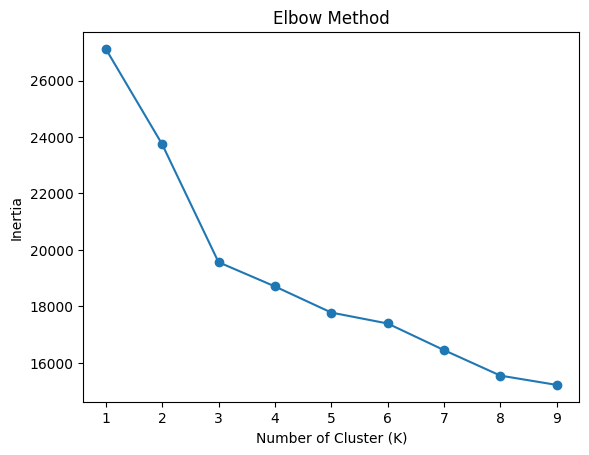

In [49]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 10):
	kmeans = KMeans(n_clusters=k, random_state=42)
	kmeans.fit(Scaled)
	inertia.append(kmeans.inertia_)
 
plt.plot(range(1,10),inertia,marker = 'o')
plt.xlabel("Number of Cluster (K)")
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show

In [50]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(Scaled)

In [51]:
for col in df_scaled.columns:
    print(f'{col}: {df_scaled[col].dtypes}')

Age: float64
weight: float64
height: float64
Pulse rate: float64
CR: float64
Sex: float64
Staging: float64
Pain: float64
SF 36: float64
Value_Q1: float64
Value_Q2: float64
Value_Q3: float64
Value_Q4: float64
Value_Q5: float64
Value_Q6: float64
Value_Q7: float64
Value_Q8: float64
Value_Q9: float64
Value_Q10: float64
Value_Q11: float64
Value_Q12: float64
Value_Q13: float64
Value_Q14: float64
Value_Q15: float64
Value_Q16: float64
Value_Q17: float64
Value_Q18: float64
Value_Q19: float64
Value_Q20: float64
Value_Q21: float64
Value_Q22: float64
Value_Q23: float64
Value_Q24: float64
Value_Q25: float64
Value_Q26: float64
Value_Q27: float64
Value_Q28: float64
Value_Q29: float64
Value_Q30: float64
Value_Q31: float64
Value_Q32: float64
Value_Q33: float64
Value_Q34: float64
Value_Q35: float64
Value_Q36: float64
Vatta: float64
Pitta: float64
Kapha: float64
1. The built: float64
The body stature / physique (body frame, height): float64
Unnamed: 96: float64
The body parts look like: float64
The body 

In [52]:
df_scaled

,Age,weight,height,Pulse rate,CR,Sex,Staging,Pain,SF 36,Value_Q1,...,Site_nasopharyngeal carcinoma,Site_oral cavity,Site_oropharyngeal,Site_other,Site_sinonasal carcinoma,Site_supraglottic,Tumorsize,Lymphnodes,Metastasis,Vata
0,0.474368,0.535733,-0.875668,0.167696,-1.879085,-0.449586,-0.154926,0.593272,0.492212,1.152476,...,-0.203653,-0.614857,-0.336601,-0.215166,-0.266627,-0.456679,-1.499754,1.091897,-0.066667,0.690742
1,0.539619,-0.344817,-1.346861,1.554257,-1.882600,-0.449586,-0.154926,1.554415,-0.190807,-0.881729,...,-0.203653,-0.614857,-0.336601,4.647580,-0.266627,-0.456679,-0.051274,-0.094491,-0.066667,0.690742
2,0.213365,0.095458,-0.561540,1.323163,-1.901634,-0.449586,2.346017,0.112700,-0.105430,-0.881729,...,-0.203653,-0.614857,-0.336601,4.647580,-0.266627,-0.456679,-1.499754,-1.280880,-0.066667,0.690742
3,-0.439144,-0.168707,1.794425,0.090665,-1.879673,-0.449586,-1.405397,1.554415,-2.427694,-0.881729,...,-0.203653,-0.614857,2.970873,-0.215166,-0.266627,-0.456679,1.397206,1.091897,-0.066667,0.690742
4,0.670121,-0.168707,1.794425,1.092070,-1.880914,-0.449586,2.346017,0.112700,0.919099,1.152476,...,-0.203653,-0.614857,2.970873,-0.215166,-0.266627,-0.456679,-1.499754,-1.280880,-0.066667,0.690742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,0.539619,0.535733,0.380846,0.398789,1.421334,-0.449586,1.095546,-0.848443,0.919099,1.152476,...,-0.203653,-0.614857,-0.336601,-0.215166,-0.266627,-0.456679,-0.051274,-1.280880,-0.066667,0.690742
222,-0.112890,0.007403,0.223782,0.013634,1.452464,-0.449586,-1.405397,-0.848443,0.475136,1.152476,...,-0.203653,1.626395,-0.336601,-0.215166,-0.266627,-0.456679,1.397206,1.091897,-0.066667,-1.447719
223,1.126877,-0.697038,-1.189797,0.475821,1.422678,-0.449586,1.095546,-0.367871,-0.634769,-0.881729,...,-0.203653,-0.614857,-0.336601,-0.215166,-0.266627,-0.456679,-0.051274,-1.280880,-0.066667,0.690742
224,1.453132,-1.489533,0.380846,0.244727,1.425511,-0.449586,-0.154926,-0.848443,0.833721,-0.881729,...,-0.203653,-0.614857,2.970873,-0.215166,-0.266627,-0.456679,-0.051274,-0.094491,-0.066667,0.690742


In [58]:
X = df_scaled.drop(columns=['SF 36'])
y = df_scaled['SF 36']

In [59]:
X.isnull().sum()

Age                  0
weight               0
height               0
Pulse rate           0
CR                   0
                    ..
Site_supraglottic    0
Tumorsize            0
Lymphnodes           0
Metastasis           0
Vata                 0
Length: 142, dtype: int64

In [60]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [61]:
print(X_train.isnull().sum().sum())

0


In [62]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(model):
    y_pred = model.predict(X_test)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

evaluate(lr)
evaluate(rf)
evaluate(xgb)

MAE: 0.002446122624200298
MSE: 0.00023550784784029822
R2: 0.9998055163092038
MAE: 0.27853101426269317
MSE: 0.15641460916529049
R2: 0.8708319456702569
MAE: 0.27329648255577504
MSE: 0.14670408378919805
R2: 0.87885095154217


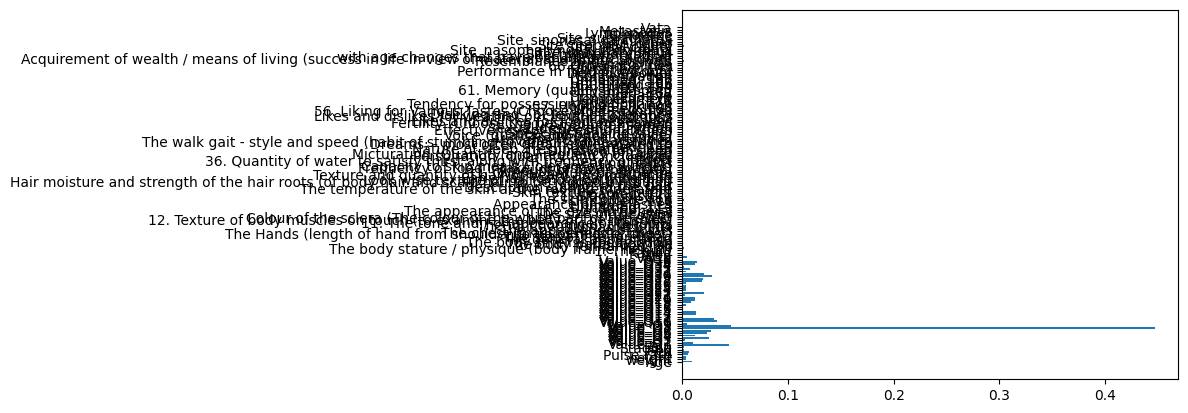

In [67]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.show()

: 

: 

: 

: 